In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

from delphi.grad import TruncatedUnknownVarianceMSE

import torch as ch
import matplotlib.pyplot as plt
%matplotlib notebook
import numpy as np
from sklearn.linear_model import LinearRegression

ch.set_printoptions(precision=4, sci_mode=False)

In [19]:
import math

class TruncatedUnknownVarianceMSE(ch.autograd.Function):
    """Corrected: L = λ/2 * [y² - 2yμ - E[z²] + 2μE[z]]"""
    @staticmethod
    def forward(ctx, pred, targ, lambda_, phi, num_samples=100, eps=1e-5):
        sigma = 1 / ch.sqrt(lambda_)
        stacked = pred[..., None].repeat(1, num_samples, 1)
        noised = stacked + sigma * ch.randn(stacked.size())
        filtered = phi(noised)
        out = noised * filtered
        z = out.sum(dim=1) / (filtered.sum(dim=1) + eps)
        z_2 = out.pow(2).sum(dim=1) / (filtered.sum(dim=1) + eps)
                
        P_hat = filtered.float().mean(dim=1)
        
        m = pred # Assume pred is m = w^T x
        mu = lambda_ * m
        sigma_sq = 1.0 / lambda_

        # 1. Term A (Quadratic term)
        quadratic_term = 0.5 * (lambda_ * targ.pow(2) - 2 * targ * mu)
        
        # 2. Term B (Log-Integral I(mu, lambda))
        
        # Part 1: (1/2) * m^2 * lambda
        m_sq_lambda_term = 0.5 * m.pow(2) * lambda_ 
        
        # Part 2: log[ sqrt(2*pi*sigma^2) * P(Z in S) ]
        log_normalization = ch.log(ch.sqrt(2 * math.pi * sigma_sq) * P_hat + eps)
        
        log_integral = m_sq_lambda_term + log_normalization
        
        # Final Loss: L = Term A + log_integral (Term B)
        loss = quadratic_term + log_integral
        
        # The return value for a log-likelihood minimization is usually the mean of the loss:
        ctx.save_for_backward(pred, targ, lambda_, z, z_2)
        return loss

    @staticmethod
    def backward(ctx, grad_output):
        pred, targ, lambda_, z, z_2 = ctx.saved_tensors
        
        # ∂L/∂μ = λ/2 * [-2y + 2E[z]]= λ(E[z] - y)
        pred_grad = lambda_ * (z - targ) / pred.size(0)
        
        # ∂L/∂λ = 1/2 * [y² - 2yμ - E[z²] + 2μE[z]]
        lambda_grad =  0.5 * (targ.pow(2) - 2*targ*pred - z_2 + 2*pred*z) / pred.size(0)
        
        return -pred_grad, None, lambda_grad, None, None, None

In [2]:
def trunc_mse(pred, targ, lambda_, phi, seed=69): 
    if seed is not None:
        ch.manual_seed(seed)
    lambda_.requires_grad = True
    pred.requires_grad = True
    loss = TruncatedUnknownVarianceMSE.apply(pred, targ, lambda_, phi)
    loss = loss.mean(0)
    loss.backward()
    return loss, pred.grad, lambda_.grad

In [3]:
W = ch.ones(1)
print(f'groud truth W:\n {W}')

X = ch.rand(1000, 1)
print(f'ground truth num samples: {X.size(0)}')

Y = X @ W + ch.randn(X.size(0))

gt_lin_reg = LinearRegression(fit_intercept=False)
gt_lin_reg.fit(X, Y)

W_fit = gt_lin_reg.coef_

print(f'W fit:\n {W_fit}')

groud truth W:
 tensor([1.])
ground truth num samples: 1000
W fit:
 [0.9874183]


In [68]:
def phi(X): 
    return X > 0

trunc_indices = phi(Y).nonzero()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices.flatten()]

trunc_lin_reg = LinearRegression(fit_intercept=False)
trunc_lin_reg.fit(X_trunc, Y_trunc)

print(f'trunc lin reg W:\n {trunc_lin_reg.coef_}')

alpha:
 0.679
trunc lin reg W:
 [[1.6133484]]


<IPython.core.display.Javascript object>


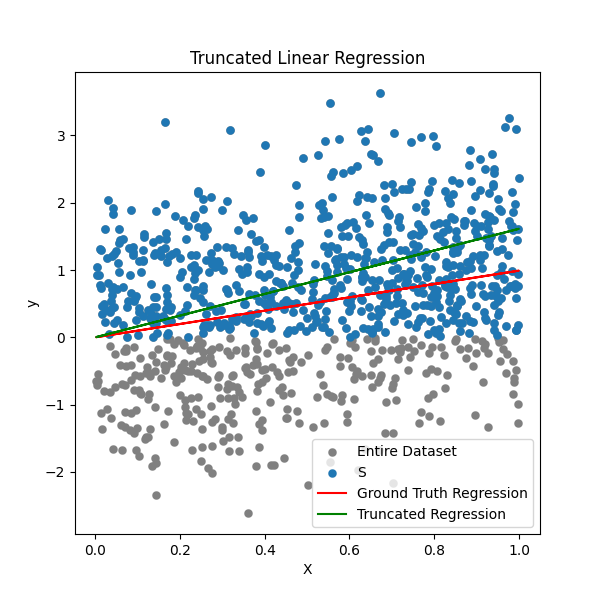

In [69]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(X, Y, linewidths=.1, color='grey', label='Entire Dataset')
ax.scatter(X_trunc, Y_trunc, linewidths=.1, label='S')
ax.plot(X.sort()[0], gt_lin_reg.predict(X.sort()[0]), color='red', label='Ground Truth Regression')
ax.plot(X.sort()[0], trunc_lin_reg.predict(X.sort()[0]), color='green', label='Truncated Regression')
ax.set_xlabel('X')
ax.set_ylabel('y')
ax.set_title('Truncated Linear Regression')
ax.legend()
plt.show()

# Vary w

<IPython.core.display.Javascript object>


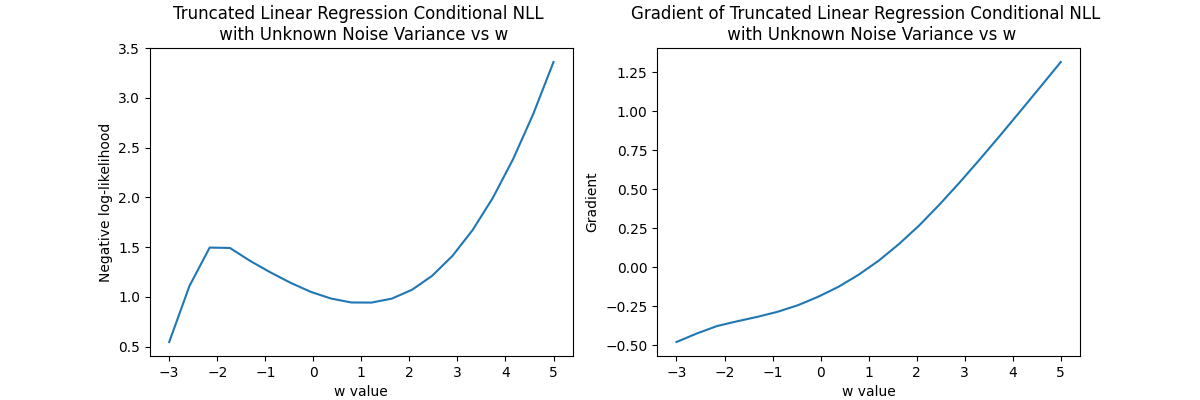

In [70]:
ws = ch.linspace(-3, 5, 20)

losses = ch.Tensor([])
grads = ch.Tensor([])

for w in ws: 
    loss, pred_grad, lambda_grad = trunc_mse(X_trunc @ w.reshape(1, 1), Y_trunc, ch.ones(1, 1), phi, ch.ones(1))
    losses = ch.cat([losses, loss[...,None].mean(0).detach()])
    grads = ch.cat([grads, (pred_grad * X_trunc).sum(0)])
    
# === Plot the loss landscape ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ws, losses)
ax1.set_xlabel("w value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Linear Regression Conditional NLL \n with Unknown Noise Variance vs w")

ax2.plot(ws, grads)
ax2.set_xlabel("w value")
ax2.set_ylabel("Gradient")
ax2.set_title("Gradient of Truncated Linear Regression Conditional NLL \n with Unknown Noise Variance vs w")

plt.show()

# Vary Sigma

<IPython.core.display.Javascript object>


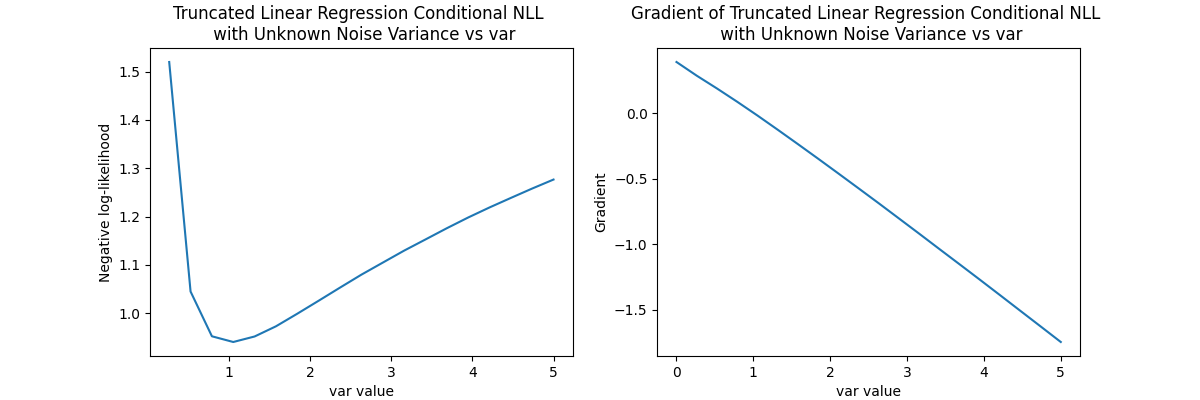

In [71]:
vars_ = ch.linspace(0, 5, 20)

losses = ch.Tensor([])
grads = ch.Tensor([])

for var in vars_: 
    loss, pred_grad, lambda_grad = trunc_mse(X_trunc @ W.reshape(1, 1), Y_trunc, 1/ch.Tensor([[var]]), phi, ch.ones(1))
    losses = ch.cat([losses, loss[...,None].mean(0).detach()])
    grads = ch.cat([grads, lambda_grad.sum(0)])
    
# === Plot the loss landscape ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(vars_, losses)
ax1.set_xlabel("var value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Linear Regression Conditional NLL \n with Unknown Noise Variance vs var")

ax2.plot(vars_, grads)
ax2.set_xlabel("var value")
ax2.set_ylabel("Gradient")
ax2.set_title("Gradient of Truncated Linear Regression Conditional NLL \n with Unknown Noise Variance vs var")

plt.show()

Ground truth: w=1.000, var=1.000
Minimum found: w=1.067, w0=0.946, loss=0.946

Loss at ground truth: 0.946
Loss at minimum: 0.946
Difference: 0.000


<IPython.core.display.Javascript object>


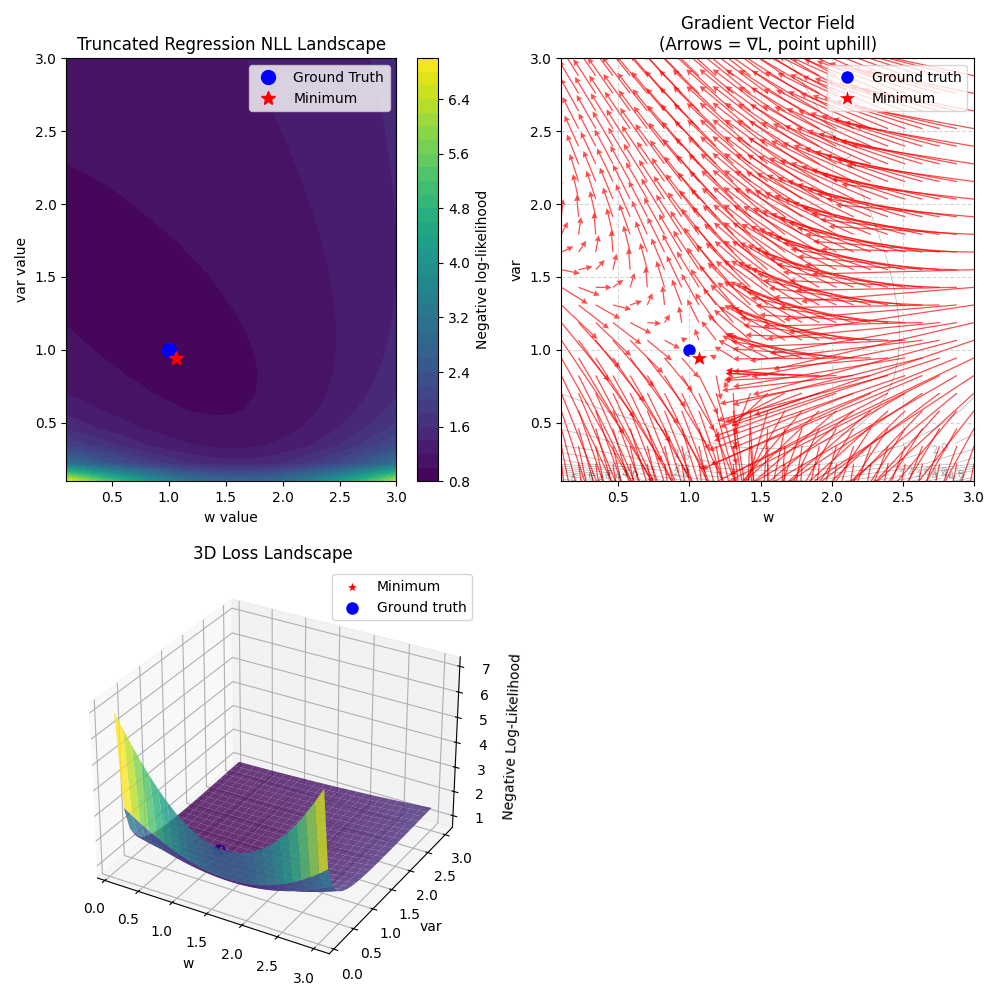

In [22]:
# === Parameter grids ===
W_values = ch.linspace(.1, 3, 25)
VAR_values = ch.linspace(.1, 3, 25)
W_, VAR_ = ch.meshgrid(W_values, VAR_values)

X_trunc_ones = ch.cat([X_trunc, ch.ones_like(X_trunc)], dim=1)

# === Compute NLL over the grid ===
Z = np.zeros_like(W_)
GRAD_W = ch.zeros_like(W_)
GRAD_VAR = ch.zeros_like(VAR_)
for i in range(len(W_values)):
    for j in range(len(VAR_values)):
        trunc_pred = X_trunc @ W_[i, j].reshape(1, 1)
        loss, pred_grad, lambda_grad = trunc_mse(trunc_pred, Y_trunc, 1/VAR_[i, j], phi)
    
        grad_ = (pred_grad * X_trunc).sum(0)

        Z[i, j] = loss
        GRAD_W[i, j] = grad_
        dlambda_dvar = -1.0 / VAR_[i, j].pow(2)
        grad_var = lambda_grad * dlambda_dvar
        GRAD_VAR[i, j] = grad_var
    
# Find the minimum point 
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
W_min, VAR_min = W_[min_idx], VAR_[min_idx]
min_loss = Z[min_idx]

print(f"Ground truth: w={W.item():.3f}, var={ch.ones(1, 1).item():.3f}")
print(f"Minimum found: w={W_min:.3f}, w0={VAR_min:.3f}, loss={min_loss:.3f}")
gt_loss = trunc_mse((X_trunc @ W.reshape(1, 1)), Y_trunc, ch.ones(1, 1), phi)[0].item()
print(f"\nLoss at ground truth: {gt_loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {gt_loss - min_loss:.3f}")

# === Plot the loss landscape ===
fig = plt.figure(figsize=(10, 10))

ax1 = fig.add_subplot(221)

cp = ax1.contourf(W_, VAR_, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("Truncated Regression NLL Landscape")
ax1.set_xlabel("w value")
ax1.set_ylabel("var value")

# mark the ground truth
ax1.plot(W.item(), ch.ones(1).item(), 'bo', markersize=10, label="Ground Truth")
ax1.plot(W_min.item(), VAR_min.item(), 'r*', markersize=10, label="Minimum")
ax1.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(222)

# Plot quiver
Q = ax4.quiver(W_, VAR_, GRAD_W, GRAD_VAR,
               color='red', alpha=0.7, width=0.003, scale=1, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(W_, VAR_, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(W.item(), ch.ones(1).item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')
ax4.plot(W_min, VAR_min, 'r*', markersize=15, markeredgecolor='white', label='Minimum')

ax4.set_xlabel('w')
ax4.set_ylabel('var')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)

# Plot 1: 3D surface plot
ax3 = fig.add_subplot(223, projection='3d')
surf = ax3.plot_surface(W_, VAR_, Z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True)
ax3.scatter([W_min], [VAR_min], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax3.scatter([W.item()], [ch.ones(1, 1).sqrt().item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax3.set_xlabel('w')
ax3.set_ylabel('var')
ax3.set_zlabel('Negative Log-Likelihood')
ax3.set_title('3D Loss Landscape')
ax3.legend()

plt.tight_layout()
plt.show()

# Run Procedure - 1 Dimension No Intercept

In [4]:
W = ch.ones(1)
NOISE_VAR = 1.0
print(f'groud truth W:\n {W}')

X = ch.rand(5000, 1)
print(f'ground truth num samples: {X.size(0)}')

Y = X @ W + NOISE_VAR**.5 * ch.randn(X.size(0))

gt_lin_reg = LinearRegression(fit_intercept=False)
gt_lin_reg.fit(X, Y)

W_fit = gt_lin_reg.coef_

print(f'W fit:\n {W_fit}')

groud truth W:
 tensor([1.])
ground truth num samples: 5000
W fit:
 [1.0839906]


In [5]:
def phi(X): 
    return X > 0

trunc_indices = phi(Y).nonzero()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices.flatten()]

trunc_lin_reg = LinearRegression(fit_intercept=False)
trunc_lin_reg.fit(X_trunc, Y_trunc)

print(f'trunc lin reg W:\n {trunc_lin_reg.coef_}')

alpha:
 0.698
trunc lin reg W:
 [[1.652842]]


In [6]:
from torch.nn import MSELoss
mse_loss = MSELoss()

gt_norm = LinearRegression(fit_intercept=False)
gt_norm.fit(X, Y)
gt_ = ch.from_numpy(gt_norm.coef_.flatten())

# calculate empirical noise variance for regression 
ols_trunc = LinearRegression(fit_intercept=False)
ols_trunc.fit(X_trunc, Y_trunc)
emp_ = ch.from_numpy(ols_trunc.coef_.flatten())
print(f'empirical weights: {emp_}')
emp_mse_loss = mse_loss(emp_, gt_)
print(f'emp mse loss: {emp_mse_loss}')

empirical weights: tensor([1.6528])
emp mse loss: 0.32359200716018677


In [7]:
from delphi.stats import TruncatedLinearRegression 
from delphi import oracle
from delphi.utils.helpers import Parameters

y_trunc_scale = Y_trunc / (NOISE_VAR ** .5)
# train algorithm
args = Parameters({'epochs': 10,
                    'lr': 1e-1,
                    'batch_size': 100,
                    'trials': 1,
                    'verbose': True,
                    'var_lr': 1e-2}) 
trunc_reg = TruncatedLinearRegression(args, 
                                      phi,
                                      alpha, 
                                      fit_intercept=False)
trunc_reg.fit(X_trunc, y_trunc_scale)

trial: 1
Creating SGD optimizer: {'lr': 0.1, 'momentum': 0.0, 'dampening': 0.0, 'weight_decay': 0.0, 'nesterov': False, 'maximize': False, 'differentiable': False}
Epoch 1 - Loss: 711.0973510742188
Epoch 2 - Loss: 983.8389282226562
Epoch 3 - Loss: 8908.1953125
Epoch 4 - Loss: 38718.9765625
Epoch 5 - Loss: 102950.703125
Epoch 6 - Loss: 329171.71875
Epoch 7 - Loss: 1056982.625
Epoch 8 - Loss: 3075803.5
Epoch 9 - Loss: 8805092.0
Epoch 10 - Loss: 25224982.0


TruncatedLinearRegression()

Ground truth: w=1.000, var=1.000
Minimum found: w=1.067, w0=0.946, loss=0.946

Loss at ground truth: 0.946
Loss at minimum: 0.946
Difference: 0.000


<IPython.core.display.Javascript object>


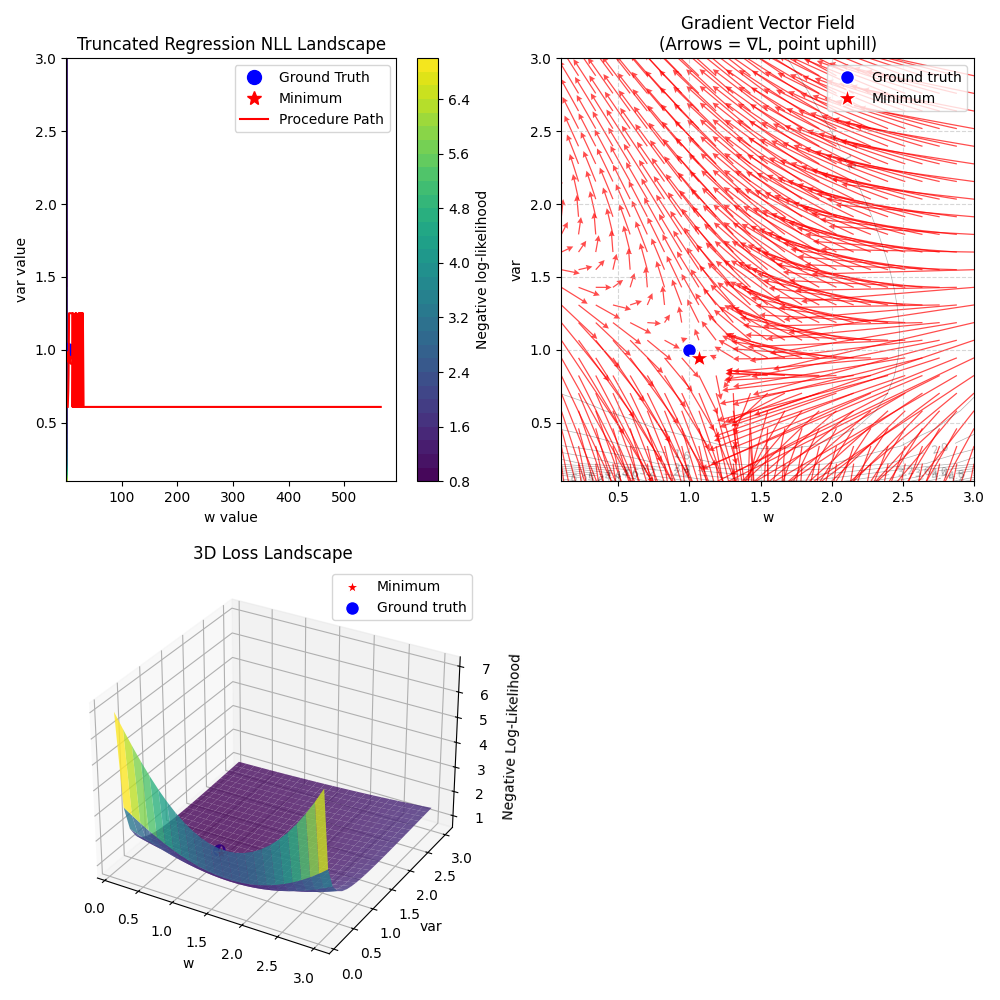

In [21]:
param_history = trunc_reg.trainer.param_history.detach()
v_ = param_history[:,0]
lambda_ = param_history[:,1]
var_ = 1/lambda_
weight_ = v_ * var_

loss_history = trunc_reg.trainer.loss_history.detach()

# === Parameter grids ===
W_values = ch.linspace(.1, 3, 25)
VAR_values = ch.linspace(.1, 3, 25)
W_, VAR_ = ch.meshgrid(W_values, VAR_values)

X_trunc_ones = ch.cat([X_trunc, ch.ones_like(X_trunc)], dim=1)

# === Compute NLL over the grid ===
Z = np.zeros_like(W_)
GRAD_W = ch.zeros_like(W_)
GRAD_VAR = ch.zeros_like(VAR_)
for i in range(len(W_values)):
    for j in range(len(VAR_values)):
        trunc_pred = X_trunc @ W_[i, j].reshape(1, 1)
        loss, pred_grad, lambda_grad = trunc_mse(trunc_pred, Y_trunc, 1/VAR_[i, j], phi)
    
        grad_ = (pred_grad * X_trunc).sum(0)

        Z[i, j] = loss
        GRAD_W[i, j] = grad_
        dlambda_dvar = -1.0 / VAR_[i, j].pow(2)
        grad_var = lambda_grad * dlambda_dvar
        GRAD_VAR[i, j] = grad_var
    
# Find the minimum point 
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
W_min, VAR_min = W_[min_idx], VAR_[min_idx]
min_loss = Z[min_idx]

print(f"Ground truth: w={W.item():.3f}, var={ch.ones(1, 1).item():.3f}")
print(f"Minimum found: w={W_min:.3f}, w0={VAR_min:.3f}, loss={min_loss:.3f}")
gt_loss = trunc_mse((X_trunc @ W.reshape(1, 1)), Y_trunc, ch.ones(1, 1), phi)[0].item()
print(f"\nLoss at ground truth: {gt_loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {gt_loss - min_loss:.3f}")

# === Plot the loss landscape ===
fig = plt.figure(figsize=(10, 10))

ax1 = fig.add_subplot(221)

cp = ax1.contourf(W_, VAR_, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("Truncated Regression NLL Landscape")
ax1.set_xlabel("w value")
ax1.set_ylabel("var value")

# mark the ground truth
ax1.plot(W.item(), ch.ones(1).item(), 'bo', markersize=10, label="Ground Truth")
ax1.plot(W_min.item(), VAR_min.item(), 'r*', markersize=10, label="Minimum")
ax1.plot(v_, var_, color="r", label="Procedure Path")
ax1.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(222)

# Plot quiver
Q = ax4.quiver(W_, VAR_, GRAD_W, GRAD_VAR,
               color='red', alpha=0.7, width=0.003, scale=1, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(W_, VAR_, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(W.item(), ch.ones(1).item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')
ax4.plot(W_min, VAR_min, 'r*', markersize=15, markeredgecolor='white', label='Minimum')

ax4.set_xlabel('w')
ax4.set_ylabel('var')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)

# Plot 1: 3D surface plot
ax3 = fig.add_subplot(223, projection='3d')
surf = ax3.plot_surface(W_, VAR_, Z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True)
ax3.scatter([W_min], [VAR_min], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax3.scatter([W.item()], [ch.ones(1, 1).sqrt().item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax3.set_xlabel('w')
ax3.set_ylabel('var')
ax3.set_zlabel('Negative Log-Likelihood')
ax3.set_title('3D Loss Landscape')
ax3.legend()

plt.tight_layout()
plt.show()

In [9]:
W_

tensor([-2.0000, -1.5556, -1.1111, -0.6667, -0.2222,  0.2222,  0.6667,  1.1111,
         1.5556,  2.0000])